# Reliability-Aware Sequential Decision-Making under Heavy-Tailed Uncertainty

<p align="center">
  <strong>Replication Data and Reproducibility Package</strong>
</p>

<p align="center">
  <em>A Localized Distributionally Robust Approach</em>
</p>

<p align="center">
  <img src="https://img.shields.io/badge/Python-3.x-blue?logo=python&logoColor=white" alt="Python">
  <img src="https://img.shields.io/badge/PyTorch-GPU%20Computing-EE4C2C?logo=pytorch&logoColor=white" alt="PyTorch">
  <img src="https://img.shields.io/badge/NVIDIA-CUDA-76B900?logo=nvidia&logoColor=white" alt="CUDA">
  <img src="https://img.shields.io/badge/Reproducibility-TRAIN%20%E2%86%92%20VALIDATION%20%E2%86%92%20TEST-success" alt="Reproducibility">
  <img src="https://img.shields.io/badge/License-CC%20BY%204.0-lightgrey" alt="License">
</p>

---

## Overview

This repository contains the computational materials associated with the study:

> **Reliability-Aware Sequential Decision-Making under Heavy-Tailed Uncertainty: A Localized Distributionally Robust Approach**

The study investigates reliability-aware sequential decision-making when heavy-tailed uncertainty is represented through a hierarchical latent model. The proposed **Localized Kullback–Leibler (Localized-KL)** construction places distributional ambiguity on the latent mixing law while maintaining the conditional disturbance mechanism and the observable information structure of the controller.

The computational experiment compares four policy-selection criteria:

- **Expected Cost**
- **Nominal Conditional Value-at-Risk (CVaR)**
- **Global-KL**
- **Localized-KL**

The empirical application uses **Bitcoin (BTCUSDT)** and **Ether (ETHUSDT)** spot-market data and preserves a strictly chronological experimental protocol.

<p>
  <a href="https://doi.org/10.5281/zenodo.23136337">
    <img src="https://img.shields.io/badge/Zenodo-Replication%20Archive-1682D4?logo=zenodo&logoColor=white" alt="Zenodo Replication Archive">
  </a>
</p>

This repository is intended to support verification and computational reproducibility of the numerical and empirical results reported in the paper. It does not imply that the maintained stochastic model exhausts all forms of market or model uncertainty.

---

## Reproducibility Design

The experimental protocol is deliberately sequential:

```text
┌─────────────────┐
│      TRAIN      │
│                 │
│ Fit / freeze    │
│ environment     │
│       ↓         │
│ Numerical gates │
│       ↓         │
│ Select policy   │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│   VALIDATION    │
│                 │
│ Confirm frozen  │
│ TRAIN choices   │
│                 │
│   NO RETUNING   │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│      TEST       │
│                 │
│ Frozen policies │
│       ↓         │
│ Final held-out  │
│ evaluation      │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ POST-TEST I.7   │
│                 │
│ Integrity audit │
│ Paired inference│
│ Tables / figures│
└─────────────────┘
```

The protocol prevents TEST information from entering policy selection. Policies are selected on TRAIN, frozen before subsequent evaluation, and VALIDATION is used without retuning.

The final statistical analysis is performed only after completion of the locked TEST stage.

---

## Experimental Design

| Component | Specification |
|---|---|
| Assets | BTCUSDT, ETHUSDT |
| Decision horizon | $T=120$ |
| Temporal grid | 5 seconds |
| Tail level | $\alpha=0.95$ |
| Policy grid | $\gamma \in \{0.0,0.1,\ldots,1.0\}$ |
| Objectives | Expected Cost, Nominal CVaR, Global-KL, Localized-KL |
| Localized-KL sensitivity grid | $\epsilon \in \{0,0.02,0.04,0.08,0.12,0.16\}$ |
| Evaluation seeds | 15 predeclared seeds |
| TEST simulations | $\geq 20,000$ trajectories per selected policy and seed |
| Asset pooling | None |
| Variance reduction | Common random numbers within admissible comparisons |
| Policy information | Observable state/history only |

BTC and ETH are analyzed separately throughout the experimental protocol.

The latent variable is part of the probabilistic representation used for robust evaluation and is **never supplied as an input to the policy**.

---

In [1]:
# Imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.ticker import (
    FuncFormatter,
    MaxNLocator
)



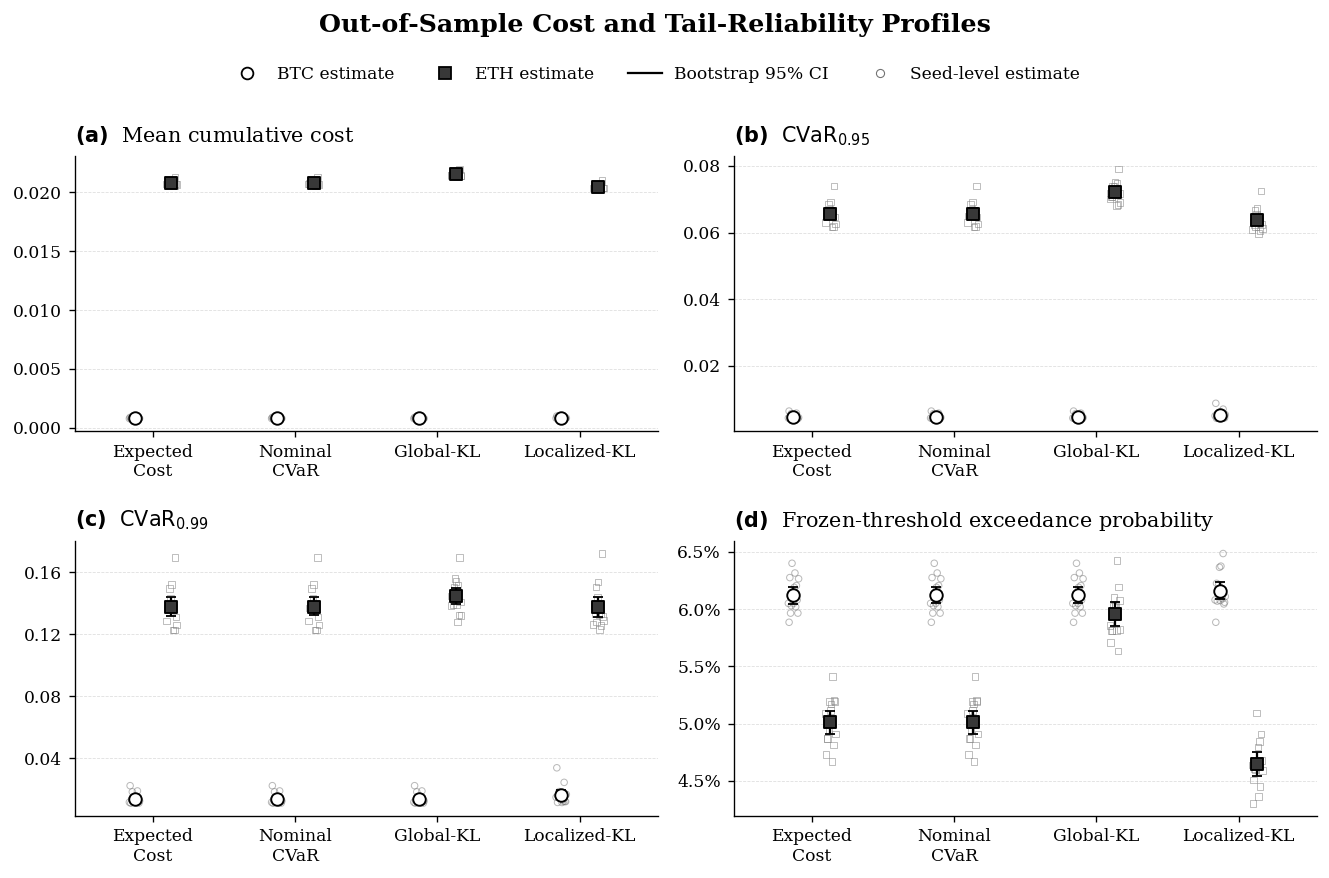

In [2]:
# -------------------------------------------------------------------------
# Figure 1
# -------------------------------------------------------------------------


data_test_summary = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"Results_RESS_V1I7/tables/I7_TEST_SUMMARY.csv"
)

data_test_boot = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"TEST_BOOTSTRAP_CI.csv"
)

data_test_seed = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"TEST_SEED_METRICS.csv"
)

required_summary = {
    "asset", "objective", "gamma", "metric",
    "estimate", "sd_across_seeds",
    "ci025_i6", "ci975_i6", "n_seeds"
}

required_boot = {
    "asset", "objective", "metric",
    "estimate", "ci025", "ci975",
    "n_seeds", "bootstrap_reps"
}

required_seed = {
    "asset", "seed", "objective", "gamma", "n",
    "mean", "cvar95", "cvar99",
    "train_frozen_exceedance_threshold",
    "exceedance_rate",
    "mean_excess_given_exceedance",
    "completion"
}


expected_assets = ["BTCUSDT", "ETHUSDT"]

expected_objectives = ["expected_cost", "nominal_cvar", "global_kl", "localized_kl"]

metrics = ["mean", "cvar95", "cvar99", "exceedance_rate"]

seed_counts = (data_test_seed.groupby(["asset", "objective"])["seed"].nunique())

gamma_counts = (data_test_seed.groupby(["asset", "objective"])["gamma"].nunique())

boot_counts = (data_test_boot[data_test_boot["metric"].isin(metrics)].groupby(["asset", "objective", "metric"]).size())

boot_check = data_test_boot[data_test_boot["metric"].isin(metrics)].copy()

check_summary = (data_test_summary[data_test_summary["metric"].isin(metrics)][["asset", "objective", "metric", "estimate", "ci025_i6", "ci975_i6"]].copy())

check_boot = (data_test_boot[data_test_boot["metric"].isin(metrics)][["asset", "objective", "metric", "estimate", "ci025", "ci975"]].copy())

check = check_summary.merge(
    check_boot,
    on=["asset", "objective", "metric"],
    suffixes=("_i7", "_i6"),
    validate="one_to_one"
)

max_estimate_error = np.max(np.abs(check["estimate_i7"] - check["estimate_i6"]))

max_lower_error = np.max(np.abs(check["ci025_i6"] - check["ci025"]))

max_upper_error = np.max(np.abs(check["ci975_i6"] - check["ci975"]))

gamma_table = (data_test_seed.groupby(["asset", "objective"], as_index=False)["gamma"].first())

objective_labels = {
    "expected_cost": "Expected\nCost",
    "nominal_cvar":  "Nominal\nCVaR",
    "global_kl":     "Global-KL",
    "localized_kl":  "Localized-KL"
}

metric_titles = {
    "mean":
        r"$\mathbf{(a)}$  Mean cumulative cost",

    "cvar95":
        r"$\mathbf{(b)}$  $\mathrm{CVaR}_{0.95}$",

    "cvar99":
        r"$\mathbf{(c)}$  $\mathrm{CVaR}_{0.99}$",

    "exceedance_rate":
        r"$\mathbf{(d)}$  Frozen-threshold exceedance probability"
}

asset_styles = {
    "BTCUSDT": {
        "label": "BTC",
        "marker": "o",
        "mfc": "white",
        "mec": "black",
        "seed_edge": "0.45",
        "offset": -0.13
    },

    "ETHUSDT": {
        "label": "ETH",
        "marker": "s",
        "mfc": "0.22",
        "mec": "black",
        "seed_edge": "0.50",
        "offset": +0.13
    }
}

plt.rcParams.update({

    "font.family": "serif",
    "font.size": 10.5,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "figure.dpi": 130,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.5, 6.9),
    sharex=True
)

axes = axes.ravel()

x_base = np.arange(len(expected_objectives), dtype=float)


seed_jitter = np.linspace(-0.036, +0.036,15)

for ax, metric in zip(axes, metrics):

    for p_idx, objective in enumerate(expected_objectives):

        for asset in expected_assets:
            style = asset_styles[asset]
            x_center = (x_base[p_idx] + style["offset"])
            seed_sub = (data_test_seed[(data_test_seed["asset"] == asset) &  (data_test_seed["objective"] == objective)].sort_values("seed").copy())
            assert len(seed_sub) == 15

            boot_sub = data_test_boot[
                (data_test_boot["asset"] == asset) &
                (data_test_boot["objective"] == objective) &
                (data_test_boot["metric"] == metric)
            ]

            assert len(boot_sub) == 1


            seed_values = (seed_sub[metric].to_numpy(dtype=float).copy())

            estimate = float(boot_sub["estimate"].iloc[0])

            ci_low = float(boot_sub["ci025"].iloc[0])

            ci_high = float(boot_sub["ci975"].iloc[0])

            # -------------------------------------------------------------
            # Exceedance probability displayed in percentage points
            # -------------------------------------------------------------

            if metric == "exceedance_rate":

                seed_values = 100.0 * seed_values
                estimate = 100.0 * estimate
                ci_low = 100.0 * ci_low
                ci_high = 100.0 * ci_high


            # -------------------------------------------------------------
            # A. Seed-level estimates
            # -------------------------------------------------------------

            ax.scatter(
                x_center + seed_jitter,
                seed_values,
                s=13,
                marker=style["marker"],
                facecolors="none",
                edgecolors=style["seed_edge"],
                linewidths=0.55,
                alpha=0.50,
                zorder=2
            )


            # -------------------------------------------------------------
            # B. Bootstrap 95% CI
            # -------------------------------------------------------------

            ax.errorbar(
                x_center,
                estimate,
                yerr=np.array([[estimate - ci_low], [ci_high - estimate]]),
                fmt="none",
                ecolor="black",
                elinewidth=1.25,
                capsize=3.0,
                capthick=1.0,
                zorder=4
            )

            ax.scatter(
                x_center,
                estimate,
                s=48,
                marker=style["marker"],
                facecolors=style["mfc"],
                edgecolors=style["mec"],
                linewidths=1.05,
                zorder=5
            )

    ax.set_title(
        metric_titles[metric],
        loc="left",
        fontweight="normal",
        pad=8
    )

    ax.set_xlim(-0.55, len(expected_objectives) - 0.45)
    ax.set_xticks(x_base)
    ax.set_xticklabels([objective_labels[obj] for obj in expected_objectives])

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.45,
        color="0.86",
        alpha=0.90,
        zorder=0
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.75)
    ax.spines["bottom"].set_linewidth(0.75)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[3].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=6.5,
        label="BTC estimate"
    ),

    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor="0.22",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=6.5,
        label="ETH estimate"
    ),

    Line2D(
        [0], [0],
        color="black",
        linewidth=1.25,
        marker="_",
        markersize=7,
        label="Bootstrap 95% CI"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor="0.45",
        markeredgewidth=0.6,
        markersize=4.5,
        label="Seed-level estimate"
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.943),
    ncol=4,
    frameon=False,
    columnspacing=2.0,
    handletextpad=0.7,
    fontsize=9.5
)

fig.suptitle(
    "Out-of-Sample Cost and Tail-Reliability Profiles",
    fontsize=14.0,
    fontweight="bold",
    y=0.985
)

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.090,
    top=0.825,
    wspace=0.13,
    hspace=0.40
)

plt.show()


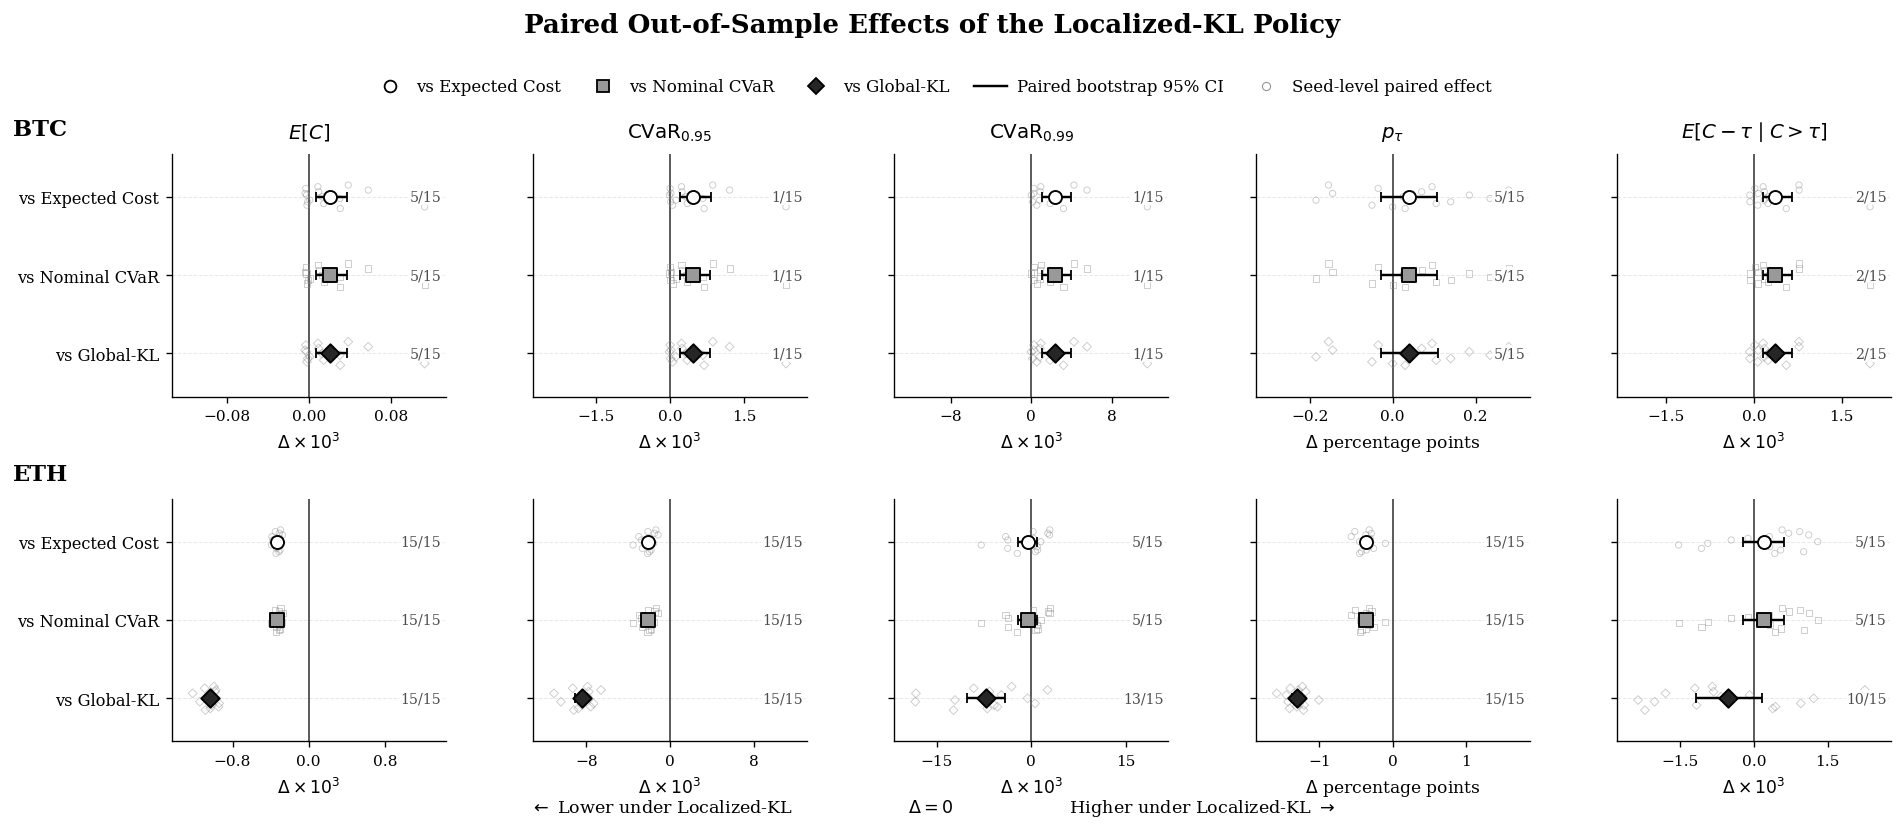

In [3]:
# -------------------------------------------------------------------------
# Figure 2
# -------------------------------------------------------------------------


data_paired_diff = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"Results_RESS_V1I7/tables/I7_PAIRED_DIFFERENCES.csv"
)

data_paired_boot = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"Results_RESS_V1I7/tables/I7_PAIRED_BOOTSTRAP_CI.csv"
)

data_test_seed = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"TEST_SEED_METRICS.csv"
)


required_diff = {
    "asset",
    "comparator",
    "metric",
    "seed",
    "localized",
    "comparator_value",
    "delta_localized_minus_comparator",
    "improvement_signed_positive_is_better"
}

required_boot = {
    "asset",
    "comparator",
    "metric",
    "localized_estimate",
    "comparator_estimate",
    "mean_delta_localized_minus_comparator",
    "relative_delta_pct",
    "paired_ci025",
    "paired_ci975",
    "share_seeds_localized_better",
    "n_better",
    "n_ties",
    "n_seeds",
    "sign_test_p_two_sided",
    "wilcoxon_p_two_sided",
    "bootstrap_reps"
}

required_seed = {
    "asset",
    "seed",
    "objective",
    "gamma",
    "n",
    "mean",
    "cvar95",
    "cvar99",
    "train_frozen_exceedance_threshold",
    "exceedance_rate",
    "mean_excess_given_exceedance",
    "completion"
}

assets = ["BTCUSDT", "ETHUSDT"]

comparators = ["expected_cost", "nominal_cvar", "global_kl"]

metrics = ["mean", "cvar95", "cvar99", "exceedance_rate", "mean_excess_given_exceedance"]


plot_diff = data_paired_diff[data_paired_diff["metric"].isin(metrics)].copy()

plot_boot = data_paired_boot[data_paired_boot["metric"].isin(metrics)].copy()

seed_counts = (plot_diff.groupby(["asset", "comparator", "metric"])["seed"].nunique())

boot_counts = (plot_boot.groupby(["asset", "comparator", "metric"]).size())



reconstructed = []

for asset in assets:

    for comparator in comparators:

        for metric in metrics:

            localized_raw = (
                data_test_seed[(data_test_seed["asset"] == asset) & (data_test_seed["objective"] == "localized_kl")][["seed", metric]]
                .rename(columns={metric: "localized_reconstructed"})
            )

            comparator_raw = (
                data_test_seed[(data_test_seed["asset"] == asset) & (data_test_seed["objective"] == comparator)][["seed", metric]]
                .rename(columns={metric: "comparator_reconstructed"})
            )

            tmp = localized_raw.merge(
                comparator_raw,
                on="seed",
                validate="one_to_one"
            )
            tmp["asset"] = asset
            tmp["comparator"] = comparator
            tmp["metric"] = metric
            tmp["delta_reconstructed"] = (tmp["localized_reconstructed"] - tmp["comparator_reconstructed"])

            reconstructed.append(tmp)


reconstructed = pd.concat(reconstructed, ignore_index=True)

audit = plot_diff.merge(
    reconstructed[["asset", "comparator", "metric", "seed", "delta_reconstructed"]],
    on=["asset", "comparator", "metric", "seed"],
    validate="one_to_one"
)

max_delta_reconstruction_error = np.max(np.abs(audit["delta_localized_minus_comparator"] - audit["delta_reconstructed"]))


paired_means = (
    plot_diff
    .groupby(["asset", "comparator", "metric"], as_index=False)["delta_localized_minus_comparator"]
    .mean()
    .rename(columns={"delta_localized_minus_comparator": "mean_delta_reconstructed"})
)

audit_boot = plot_boot.merge(
    paired_means,
    on=["asset", "comparator", "metric"],
    validate="one_to_one"
)

max_boot_mean_error = np.max(np.abs(audit_boot["mean_delta_localized_minus_comparator"] - audit_boot["mean_delta_reconstructed"]))

better_raw = (
    plot_diff
    .assign(localized_lower=lambda x: x["delta_localized_minus_comparator"] < 0)
    .groupby(["asset", "comparator", "metric"], as_index=False)["localized_lower"]
    .sum()
    .rename(columns={"localized_lower": "n_lower_reconstructed"})
)

audit_better = plot_boot.merge(
    better_raw,
    on=["asset", "comparator", "metric"],
    validate="one_to_one"
)


metric_scale = {
    "mean": 1000.0,
    "cvar95": 1000.0,
    "cvar99": 1000.0,
    "exceedance_rate": 100.0,
    "mean_excess_given_exceedance": 1000.0
}

metric_titles = {

    "mean":
        r"$E[C]$",

    "cvar95":
        r"$\mathrm{CVaR}_{0.95}$",

    "cvar99":
        r"$\mathrm{CVaR}_{0.99}$",

    "exceedance_rate":
        r"$p_{\tau}$",

    "mean_excess_given_exceedance":
        r"$E[C-\tau\mid C>\tau]$"
}

metric_units = {

    "mean":
        r"$\Delta \times 10^{3}$",

    "cvar95":
        r"$\Delta \times 10^{3}$",

    "cvar99":
        r"$\Delta \times 10^{3}$",

    "exceedance_rate":
        r"$\Delta$ percentage points",

    "mean_excess_given_exceedance":
        r"$\Delta \times 10^{3}$"
}

comparator_styles = {

    "expected_cost": {
        "label": "Expected Cost",
        "marker": "o",
        "facecolor": "white",
        "edgecolor": "black"
    },

    "nominal_cvar": {
        "label": "Nominal CVaR",
        "marker": "s",
        "facecolor": "0.60",
        "edgecolor": "black"
    },

    "global_kl": {
        "label": "Global-KL",
        "marker": "D",
        "facecolor": "0.15",
        "edgecolor": "black"
    }
}

y_positions = {
    "expected_cost": 2.0,
    "nominal_cvar": 1.0,
    "global_kl": 0.0
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10.0,
    "axes.titlesize": 11.0,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 9.0,
    "legend.fontsize": 9.5,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "figure.dpi": 130,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})



fig, axes = plt.subplots(
    2,
    5,
    figsize=(15.2, 6.6),
    sharey=True
)

for row_idx, asset in enumerate(assets):

    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        scale = metric_scale[metric]

        # ---------------------------------------------------------------------
        # Zero-effect reference
        # ---------------------------------------------------------------------

        ax.axvline(
            0.0,
            color="0.30",
            linewidth=1.0,
            linestyle="-",
            zorder=1
        )

        for comparator in comparators:
            ax.axhline(
                y_positions[comparator],
                color="0.91",
                linewidth=0.55,
                linestyle="--",
                zorder=0
            )

        # ---------------------------------------------------------------------
        # Comparator effects
        # ---------------------------------------------------------------------

        for comparator in comparators:
            style = comparator_styles[comparator]
            y = y_positions[comparator]
            raw = (plot_diff[(plot_diff["asset"] == asset) & (plot_diff["metric"] == metric) & (plot_diff["comparator"] == comparator)].sort_values("seed").copy())
            agg = plot_boot[(plot_boot["asset"] == asset) & (plot_boot["metric"] == metric) & (plot_boot["comparator"] == comparator)].copy()

            assert len(raw) == 15
            assert len(agg) == 1

            raw_delta = (raw["delta_localized_minus_comparator"].to_numpy(dtype=float) * scale)
            estimate = (float(agg["mean_delta_localized_minus_comparator"].iloc[0]) *  scale)
            ci_low = (float(agg["paired_ci025"].iloc[0]) * scale)
            ci_high = (float(agg["paired_ci975"].iloc[0]) * scale)
            n_better = int(agg["n_better"].iloc[0])
            n_seeds = int(agg["n_seeds"].iloc[0])
            y_jitter = np.linspace(-0.15, +0.15, 15)

            ax.scatter(
                raw_delta,
                y + y_jitter,
                s=12,
                marker=style["marker"],
                facecolors="none",
                edgecolors="0.55",
                linewidths=0.50,
                alpha=0.45,
                zorder=2
            )

            ax.errorbar(
                estimate,
                y,
                xerr=np.array([[estimate - ci_low], [ci_high - estimate]]),
                fmt="none",
                ecolor="black",
                elinewidth=1.35,
                capsize=3.0,
                capthick=1.0,
                zorder=4
            )

            ax.scatter(
                estimate,
                y,
                s=52,
                marker=style["marker"],
                facecolors=style["facecolor"],
                edgecolors=style["edgecolor"],
                linewidths=1.05,
                zorder=5
            )

            ax.text(
                0.985,
                y,
                f"{n_better}/{n_seeds}",
                transform=ax.get_yaxis_transform(),
                ha="right",
                va="center",
                fontsize=7.8,
                color="0.30",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.82,
                    pad=0.6
                ),
                zorder=6
            )

        if row_idx == 0:
            ax.set_title(metric_titles[metric], fontweight="bold", pad=9)

        ax.set_xlabel(metric_units[metric], labelpad=5)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_linewidth(0.75)
        ax.spines["bottom"].set_linewidth(0.75)

        panel_raw = plot_diff[(plot_diff["asset"] == asset) & (plot_diff["metric"] == metric)]["delta_localized_minus_comparator"].to_numpy(dtype=float) * scale

        panel_boot = plot_boot[(plot_boot["asset"] == asset) & (plot_boot["metric"] == metric)].copy()

        panel_ci_low = (panel_boot["paired_ci025"].to_numpy(dtype=float) * scale)

        panel_ci_high = (panel_boot["paired_ci975"].to_numpy(dtype=float) * scale)

        panel_extent = np.max(np.abs(np.concatenate([panel_raw, panel_ci_low, panel_ci_high])))

        panel_extent = panel_extent * 1.18

        if panel_extent == 0:
            panel_extent = 1.0

        ax.set_xlim(-panel_extent, panel_extent)

        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, symmetric=True))

        ax.set_ylim(-0.55, 2.55)

for row_idx in range(2):
    axes[row_idx, 0].set_yticks([y_positions["expected_cost"], y_positions["nominal_cvar"], y_positions["global_kl"]])
    axes[row_idx, 0].set_yticklabels(["vs Expected Cost", "vs Nominal CVaR", "vs Global-KL"])


axes[0, 0].text(
    -0.58,
    1.10,
    "BTC",
    transform=axes[0, 0].transAxes,
    fontsize=12.5,
    fontweight="bold",
    ha="left",
    va="center"
)

axes[1, 0].text(
    -0.58,
    1.10,
    "ETH",
    transform=axes[1, 0].transAxes,
    fontsize=12.5,
    fontweight="bold",
    ha="left",
    va="center"
)


fig.text(
    0.50,
    0.058,
    r"$\leftarrow$ Lower under Localized-KL"
    r"                     "
    r"$\Delta=0$"
    r"                     "
    r"Higher under Localized-KL $\rightarrow$",
    ha="center",
    va="center",
    fontsize=9.7
)


legend_elements = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=6.5,
        label="vs Expected Cost"
    ),

    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor="0.60",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=6.5,
        label="vs Nominal CVaR"
    ),

    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor="0.15",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=6.0,
        label="vs Global-KL"
    ),

    Line2D(
        [0], [0],
        color="black",
        linewidth=1.35,
        marker="_",
        markersize=7,
        label="Paired bootstrap 95% CI"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor="0.55",
        markeredgewidth=0.55,
        markersize=4.5,
        label="Seed-level paired effect"
    )
]


fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.925),
    ncol=5,
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.6,
    fontsize=9.2
)

fig.suptitle(
    "Paired Out-of-Sample Effects of the Localized-KL Policy",
    fontsize=14.5,
    fontweight="bold",
    y=0.985
)


fig.subplots_adjust(
    left=0.115,
    right=0.985,
    bottom=0.135,
    top=0.82,
    wspace=0.32,
    hspace=0.42
)

plt.show()



BTCUSDT
  EXACT OVERLAP: expected_cost = global_kl
  EXACT OVERLAP: expected_cost = nominal_cvar
  EXACT OVERLAP: global_kl = nominal_cvar

ETHUSDT
  EXACT OVERLAP: expected_cost = nominal_cvar


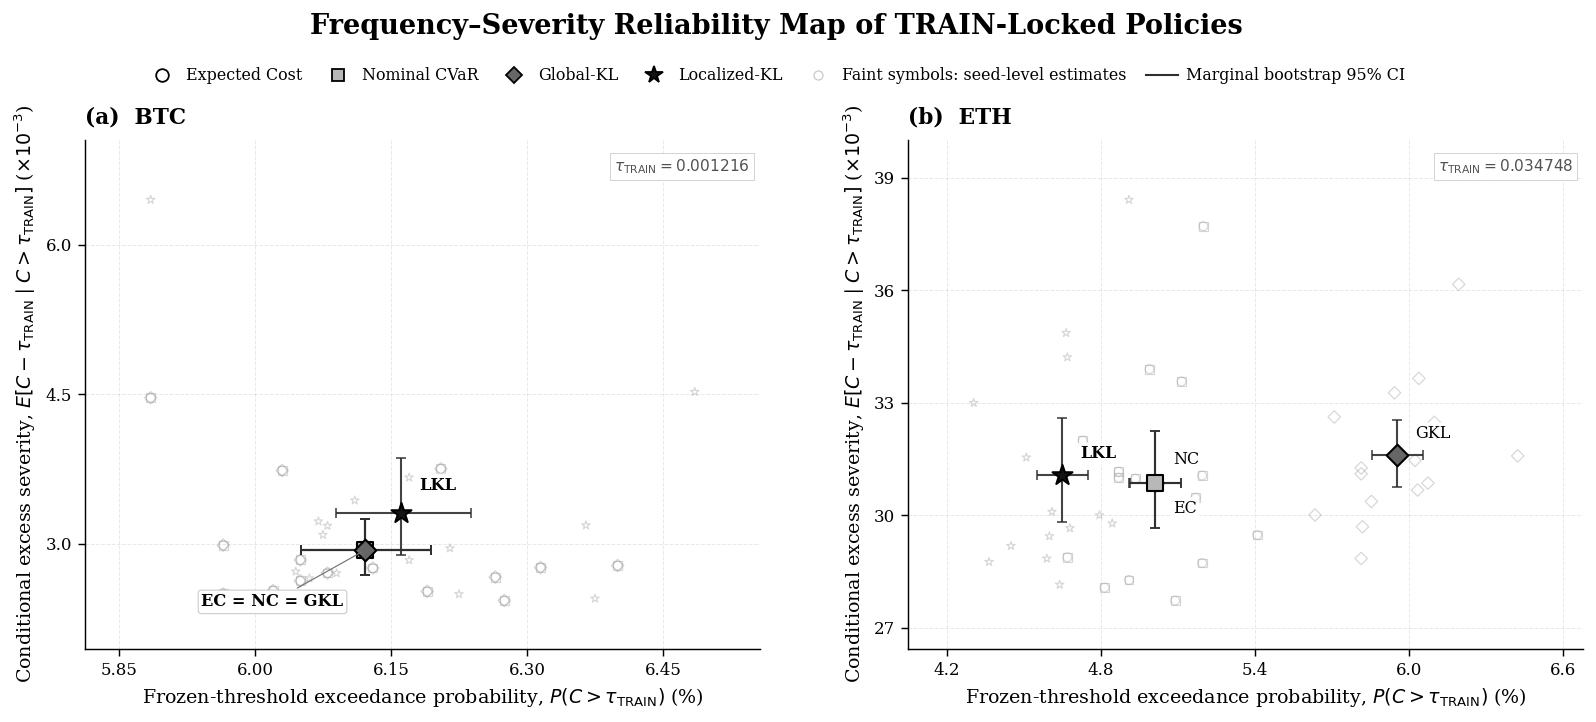

In [4]:
# -------------------------------------------------------------------------
# Figure 3
# -------------------------------------------------------------------------


data_reliability_decomp = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"Results_RESS_V1I7/tables/I7_RELIABILITY_DECOMPOSITION.csv"
)

data_test_seed = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"TEST_SEED_METRICS.csv"
)


assets = ["BTCUSDT", "ETHUSDT"]

objectives = ["expected_cost", "nominal_cvar", "global_kl", "localized_kl"]

policy_labels = {
    "expected_cost": "Expected Cost",
    "nominal_cvar": "Nominal CVaR",
    "global_kl": "Global-KL",
    "localized_kl": "Localized-KL"
}

policy_short = {
    "expected_cost": "EC",
    "nominal_cvar": "NC",
    "global_kl": "GKL",
    "localized_kl": "LKL"
}


required_decomp = {
    "asset",
    "objective",
    "gamma",
    "exceedance_rate",
    "mean_excess_given_exceedance",
    "completion",
    "frozen_threshold"
}

required_seed = {"asset", "seed", "objective", "gamma", "n", "mean", "cvar95", "cvar99",
                 "train_frozen_exceedance_threshold","exceedance_rate",
                 "mean_excess_given_exceedance", "completion"}

missing_decomp = required_decomp.difference(data_reliability_decomp.columns)
missing_seed = required_seed.difference(data_test_seed.columns)

agg_counts = (
    data_reliability_decomp.groupby(["asset", "objective"]).size())

seed_counts = (data_test_seed.groupby(["asset", "objective"])["seed"].nunique())


reconstructed = (
    data_test_seed
    .groupby(["asset", "objective", "gamma"],as_index=False)
    .agg(
        exceedance_rate_reconstructed=("exceedance_rate", "mean"),
        severity_reconstructed=("mean_excess_given_exceedance", "mean"),
        threshold_reconstructed=("train_frozen_exceedance_threshold", "mean")
    )
)

audit = data_reliability_decomp.merge(
    reconstructed,
    on=["asset", "objective", "gamma"],
    validate="one_to_one"
)

max_exceedance_error = np.max(np.abs(audit["exceedance_rate"] - audit["exceedance_rate_reconstructed"]))

max_severity_error = np.max(np.abs(audit["mean_excess_given_exceedance"] - audit["severity_reconstructed"]))

max_threshold_error = np.max(np.abs(audit["frozen_threshold"] - audit["threshold_reconstructed"]))


for asset in assets:

    agg_asset = data_reliability_decomp[data_reliability_decomp["asset"] == asset]

    seed_asset = data_test_seed[data_test_seed["asset"] == asset]


for asset in assets:

    for objective in objectives:

        g_agg = float(data_reliability_decomp[(data_reliability_decomp["asset"] == asset) & (data_reliability_decomp["objective"] == objective)]["gamma"].iloc[0])

        g_seed = (data_test_seed[(data_test_seed["asset"] == asset) & (data_test_seed["objective"] == objective)]["gamma"].unique())

        assert len(g_seed) == 1

        assert np.isclose(
            g_agg,
            g_seed[0],
            atol=1e-15,
            rtol=0.0
        )



for asset in assets:

    print(f"\n{asset}")

    tmp = (data_reliability_decomp[data_reliability_decomp["asset"] == asset].copy().reset_index(drop=True))

    overlap_found = False

    for i in range(len(tmp)):

        for j in range(i + 1, len(tmp)):

            row_i = tmp.iloc[i]
            row_j = tmp.iloc[j]

            same_x = np.isclose(
                row_i["exceedance_rate"],
                row_j["exceedance_rate"],
                atol=1e-14,
                rtol=0.0
            )

            same_y = np.isclose(
                row_i["mean_excess_given_exceedance"],
                row_j["mean_excess_given_exceedance"],
                atol=1e-14,
                rtol=0.0
            )

            if same_x and same_y:

                overlap_found = True

                print("  EXACT OVERLAP:", row_i["objective"], "=", row_j["objective"])

    if not overlap_found:
        print("  No exact aggregate overlap.")

B = 50000

rng = np.random.default_rng(20261002)

bootstrap_rows = []

for asset in assets:

    for objective in objectives:

        raw = (data_test_seed[(data_test_seed["asset"] == asset) & (data_test_seed["objective"] == objective)].sort_values("seed").copy())

        assert len(raw) == 15
        assert raw["seed"].nunique() == 15

        x = raw["exceedance_rate"].to_numpy(dtype=float)

        y = raw["mean_excess_given_exceedance"].to_numpy(dtype=float)

        n_seed = len(raw)

        bootstrap_indices = rng.integers(0, n_seed, size=(B, n_seed))

        boot_x = x[bootstrap_indices].mean(axis=1)

        boot_y = y[bootstrap_indices].mean(axis=1)

        x_low, x_high = np.quantile(boot_x,[0.025, 0.975])

        y_low, y_high = np.quantile(boot_y,[0.025, 0.975])

        bootstrap_rows.append(
            {"asset": asset,
             "objective": objective,
             "x_ci025": x_low,
             "x_ci975": x_high,
             "y_ci025": y_low,
             "y_ci975": y_high
            }
        )

bootstrap_ci = pd.DataFrame(bootstrap_rows)



plot_data = data_reliability_decomp.merge(
    bootstrap_ci,
    on=["asset", "objective"],
    validate="one_to_one"
)


plot_data["x_plot"] = (100.0 * plot_data["exceedance_rate"])

plot_data["x_low_plot"] = (100.0 * plot_data["x_ci025"])

plot_data["x_high_plot"] = (100.0 * plot_data["x_ci975"])

plot_data["y_plot"] = (1000.0 * plot_data["mean_excess_given_exceedance"])

plot_data["y_low_plot"] = (1000.0 * plot_data["y_ci025"])

plot_data["y_high_plot"] = (1000.0 * plot_data["y_ci975"])


# Seed-level display units

seed_plot = data_test_seed.copy()

seed_plot["x_plot"] = (100.0 * seed_plot["exceedance_rate"])

seed_plot["y_plot"] = (1000.0 * seed_plot["mean_excess_given_exceedance"])

policy_style = {

    "expected_cost": {
        "marker": "o",
        "facecolor": "white",
        "edgecolor": "black"
    },

    "nominal_cvar": {
        "marker": "s",
        "facecolor": "0.72",
        "edgecolor": "black"
    },

    "global_kl": {
        "marker": "D",
        "facecolor": "0.40",
        "edgecolor": "black"
    },

    "localized_kl": {
        "marker": "*",
        "facecolor": "0.08",
        "edgecolor": "black"
    }
}


eth_label_offsets = {
    "expected_cost": (10, -14),
    "nominal_cvar": (10, 13),
    "global_kl": (10, 12),
    "localized_kl": (10, 12)
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10.5,
    "axes.titlesize": 12.0,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.2,
    "ytick.labelsize": 9.2,
    "legend.fontsize": 9.3,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.8,
    "ytick.major.size": 3.8,
    "figure.dpi": 130,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# FIGURE

fig, axes = plt.subplots(1,2, figsize=(12.8, 5.8))


for ax_idx, asset in enumerate(assets):

    ax = axes[ax_idx]

    central_asset = (plot_data[plot_data["asset"] == asset].copy())

    seed_asset = (seed_plot[seed_plot["asset"] == asset].copy())

    for objective in objectives:

        style = policy_style[objective]

        raw = (seed_asset[seed_asset["objective"] == objective].sort_values("seed"))

        ax.scatter(
            raw["x_plot"],
            raw["y_plot"],
            s=24,
            marker=style["marker"],
            facecolors="none",
            edgecolors="0.62",
            linewidths=0.65,
            alpha=0.42,
            zorder=2
        )

    for objective in objectives:

        style = policy_style[objective]

        row = (central_asset[central_asset["objective"] == objective].iloc[0])

        x = float(row["x_plot"])
        y = float(row["y_plot"])

        x_low = float(row["x_low_plot"])
        x_high = float(row["x_high_plot"])

        y_low = float(row["y_low_plot"])
        y_high = float(row["y_high_plot"])

        ax.errorbar(
            x,
            y,
            xerr=np.array([[x - x_low], [x_high - x]]),
            yerr=np.array([[y - y_low], [y_high - y]]),
            fmt="none",
            ecolor="0.18",
            elinewidth=1.15,
            capsize=3.0,
            capthick=0.9,
            alpha=0.90,
            zorder=3
        )

        marker_size = (135 if objective == "localized_kl" else 72)

        ax.scatter(
            x,
            y,
            s=marker_size,
            marker=style["marker"],
            facecolors=style["facecolor"],
            edgecolors=style["edgecolor"],
            linewidths=1.15,
            zorder=5
        )

    if asset == "BTCUSDT":

        btc_common = (central_asset[central_asset["objective"] == "expected_cost"].iloc[0])

        x_common = float(btc_common["x_plot"])

        y_common = float(btc_common["y_plot"])

        ax.annotate(
            "EC = NC = GKL",
            xy=(x_common, y_common),
            xytext=(-12, -24),
            textcoords="offset points",
            ha="right",
            va="top",
            fontsize=9.0,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.20",
                facecolor="white",
                edgecolor="0.78",
                linewidth=0.6,
                alpha=0.94
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="0.45",
                linewidth=0.65
            ),
            zorder=7
        )


        btc_lkl = (central_asset[central_asset["objective"] == "localized_kl"].iloc[0])

        ax.annotate(
            "LKL",
            xy=(float(btc_lkl["x_plot"]), float(btc_lkl["y_plot"])),
            xytext=(10, 11),
            textcoords="offset points",
            ha="left",
            va="bottom",
            fontsize=9.0,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.88
            ),
            zorder=7
        )

    if asset == "ETHUSDT":

        for objective in objectives:

            row = (central_asset[central_asset["objective"] == objective].iloc[0])

            dx, dy = (eth_label_offsets[objective])

            ax.annotate(
                policy_short[objective],
                xy=(float(row["x_plot"]), float(row["y_plot"])),
                xytext=(dx, dy),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=8.8,
                fontweight=("bold" if objective == "localized_kl" else "normal"),
                bbox=dict(
                    boxstyle="round,pad=0.16",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.88
                ),
                zorder=7
            )

    all_x = np.concatenate(
        [seed_asset["x_plot"].to_numpy(dtype=float),
         central_asset["x_low_plot"].to_numpy(dtype=float),
         central_asset["x_high_plot"].to_numpy(dtype=float)
        ]
    )

    all_y = np.concatenate(
        [seed_asset["y_plot"].to_numpy(dtype=float),
         central_asset["y_low_plot"].to_numpy(dtype=float),
         central_asset["y_high_plot"].to_numpy(dtype=float)
        ]
    )

    x_min = np.min(all_x)
    x_max = np.max(all_x)

    y_min = np.min(all_y)
    y_max = np.max(all_y)

    x_range = x_max - x_min
    y_range = y_max - y_min

    if x_range == 0:
        x_range = 1.0

    if y_range == 0:
        y_range = 1.0

    ax.set_xlim(x_min - 0.12 * x_range, x_max + 0.12 * x_range)

    ax.set_ylim(max(0.0, y_min - 0.12 * y_range), y_max + 0.15 * y_range)

    panel_letter = ("(a)" if asset == "BTCUSDT" else "(b)")

    asset_name = ("BTC" if asset == "BTCUSDT" else "ETH")

    ax.set_title(
        f"{panel_letter}  {asset_name}",
        loc="left",
        fontweight="bold",
        pad=9
    )

    ax.set_xlabel(
        r"Frozen-threshold exceedance probability, "
        r"$P(C>\tau_{\mathrm{TRAIN}})$ (%)"
    )

    ax.set_ylabel(
        r"Conditional excess severity, "
        r"$E[C-\tau_{\mathrm{TRAIN}}\mid "
        r"C>\tau_{\mathrm{TRAIN}}]$ "
        r"($\times 10^{-3}$)"
    )

    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.55,
        alpha=0.28,
        zorder=0
    )

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    tau = float(central_asset["frozen_threshold"].iloc[0])

    ax.text(
        0.985,
        0.965,
        rf"$\tau_{{\mathrm{{TRAIN}}}}={tau:.6f}$",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        color="0.32",
        bbox=dict(
            facecolor="white",
            edgecolor="0.82",
            linewidth=0.55,
            alpha=0.92,
            pad=2.2
        ),
        zorder=8
    )


fig.suptitle(
    "Frequency–Severity Reliability Map of TRAIN-Locked Policies",
    fontsize=15.0,
    fontweight="bold",
    y=0.988
)

legend_elements = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=7,
        label="Expected Cost"
    ),

    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="none",
        markerfacecolor="0.72",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=7,
        label="Nominal CVaR"
    ),

    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        markerfacecolor="0.40",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=6.5,
        label="Global-KL"
    ),

    Line2D(
        [0],
        [0],
        marker="*",
        linestyle="none",
        markerfacecolor="0.08",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=10,
        label="Localized-KL"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor="0.62",
        markeredgewidth=0.7,
        markersize=5,
        alpha=0.55,
        label="Faint symbols: seed-level estimates"
    ),

    Line2D(
        [0],
        [0],
        color="0.18",
        linewidth=1.15,
        marker="_",
        markersize=7,
        label="Marginal bootstrap 95% CI"
    )
]


fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=6,
    frameon=False,
    columnspacing=1.25,
    handletextpad=0.50,
    fontsize=8.8
)

fig.subplots_adjust(
    left=0.085,
    right=0.985,
    bottom=0.145,
    top=0.82,
    wspace=0.22
)



plt.show()

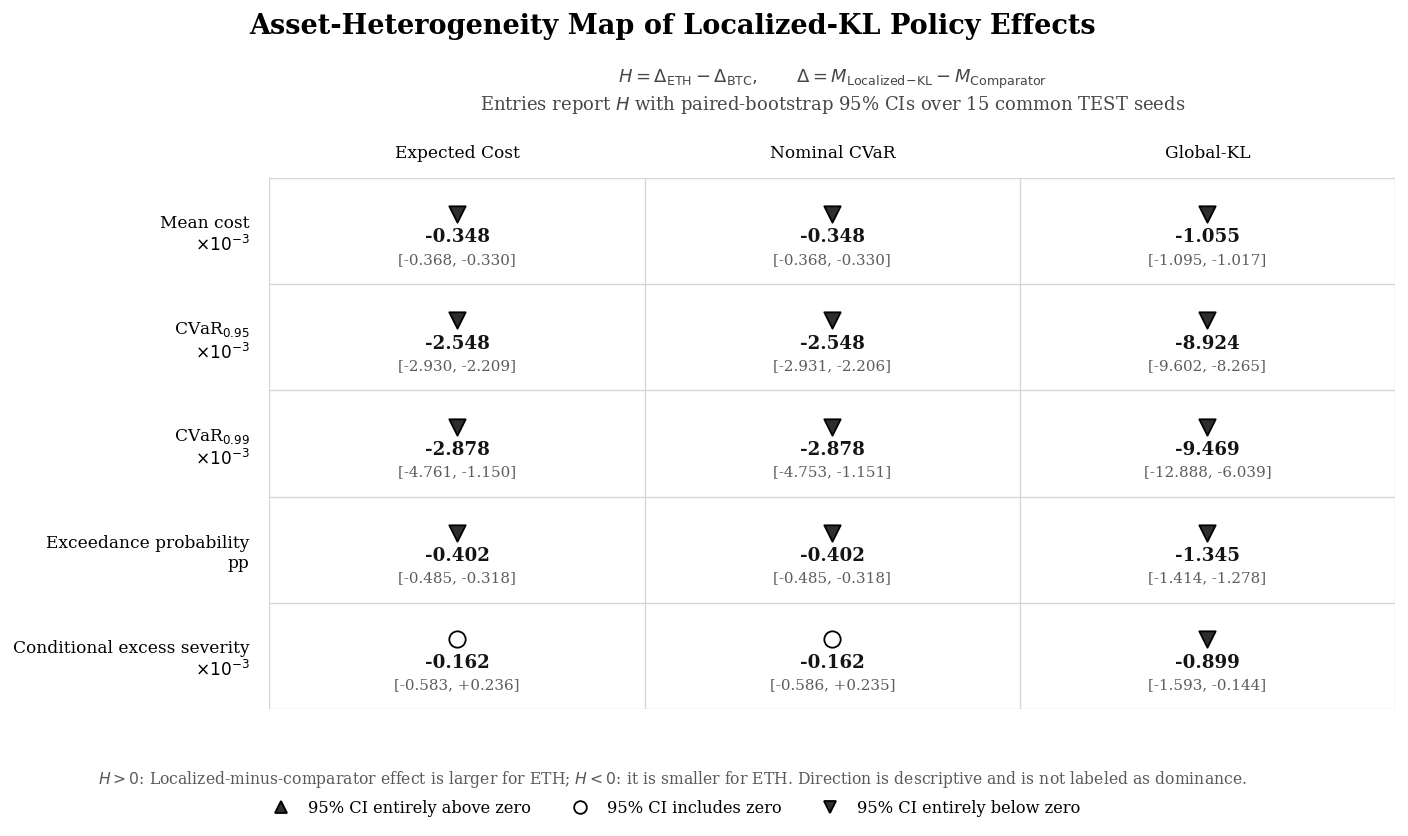

In [5]:
# -------------------------------------------------------------------------
# Figure 4
# -------------------------------------------------------------------------

data_paired_diff = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"Results_RESS_V1I7/tables/I7_PAIRED_DIFFERENCES.csv"
)

data_asset_heterogeneity = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"Results_RESS_V1I7/tables/I7_ASSET_HETEROGENEITY.csv"
)

assets = ["BTCUSDT", "ETHUSDT"]

comparators = ["expected_cost", "nominal_cvar", "global_kl"]

metrics = ["mean", "cvar95", "cvar99", "exceedance_rate", "mean_excess_given_exceedance"]


comparator_labels = {
    "expected_cost": "Expected Cost",
    "nominal_cvar": "Nominal CVaR",
    "global_kl": "Global-KL"
}


metric_labels = {
    "mean": r"Mean cost",
    "cvar95": r"CVaR$_{0.95}$",
    "cvar99": r"CVaR$_{0.99}$",
    "exceedance_rate": r"Exceedance probability",
    "mean_excess_given_exceedance": r"Conditional excess severity"
}


metric_scale = {
    "mean": 1000.0,
    "cvar95": 1000.0,
    "cvar99": 1000.0,
    "exceedance_rate": 100.0,
    "mean_excess_given_exceedance": 1000.0
}


metric_unit = {
    "mean": r"$\times 10^{-3}$",
    "cvar95": r"$\times 10^{-3}$",
    "cvar99": r"$\times 10^{-3}$",
    "exceedance_rate": "pp",
    "mean_excess_given_exceedance": r"$\times 10^{-3}$"
}

required_columns = {
    "asset",
    "comparator",
    "metric",
    "seed",
    "localized",
    "comparator_value",
    "delta_localized_minus_comparator",
    "improvement_signed_positive_is_better"
}

missing_columns = required_columns.difference(data_paired_diff.columns)


figure_data = (data_paired_diff[data_paired_diff["asset"].isin(assets) & data_paired_diff["comparator"].isin(comparators) & data_paired_diff["metric"].isin(metrics)].copy())


expected_n = (len(assets) * len(comparators) * len(metrics) * 15)


cell_counts = (figure_data.groupby(["asset", "comparator", "metric"])["seed"].nunique())


duplicate_counts = (figure_data.groupby(["asset", "comparator", "metric", "seed"]).size())

numeric_columns = ["localized", "comparator_value", "delta_localized_minus_comparator", "improvement_signed_positive_is_better"]

delta_reconstructed = (figure_data["localized"].to_numpy(dtype=float) - figure_data["comparator_value"].to_numpy(dtype=float))

delta_stored = (figure_data["delta_localized_minus_comparator"].to_numpy(dtype=float))

max_delta_identity_error = np.max(np.abs(delta_stored - delta_reconstructed))

for comparator in comparators:

    for metric in metrics:

        btc_seeds = sorted(figure_data[(figure_data["asset"] == "BTCUSDT") & (figure_data["comparator"] == comparator) & (figure_data["metric"] == metric)]["seed"].unique().tolist())

        eth_seeds = sorted(
            figure_data[(figure_data["asset"] == "ETHUSDT") & (figure_data["comparator"] == comparator) & (figure_data["metric"] == metric)]["seed"].unique().tolist())

        assert len(btc_seeds) == 15
        assert len(eth_seeds) == 15

        assert btc_seeds == eth_seeds, (
            "BTC/ETH seed pairing failed for "
            f"{comparator} / {metric}."
        )


heterogeneity_seed_rows = []

for comparator in comparators:

    for metric in metrics:

        btc = (figure_data[(figure_data["asset"] == "BTCUSDT") & (figure_data["comparator"] == comparator) & (figure_data["metric"] == metric)][["seed", "delta_localized_minus_comparator"]]
            .rename(columns={"delta_localized_minus_comparator": "delta_btc"})
            .sort_values("seed")
        )


        eth = (
            figure_data[(figure_data["asset"] == "ETHUSDT") & (figure_data["comparator"] == comparator) & (figure_data["metric"] == metric)][["seed", "delta_localized_minus_comparator"]]
            .rename(columns={"delta_localized_minus_comparator": "delta_eth"}).sort_values("seed"))

        paired = btc.merge(eth, on="seed", how="inner", validate="one_to_one")
        assert len(paired) == 15

        paired["heterogeneity_contrast"] = (paired["delta_eth"] - paired["delta_btc"])


        for _, row in paired.iterrows():

            heterogeneity_seed_rows.append(
                {"comparator": comparator,
                 "metric": metric,
                 "seed": int(row["seed"]),
                 "delta_btc": float(row["delta_btc"]),
                 "delta_eth": float(row["delta_eth"]),
                 "heterogeneity_contrast": float(row["heterogeneity_contrast"])
                }
            )


heterogeneity_seed = pd.DataFrame(heterogeneity_seed_rows)

hetero_required = {
    "comparator",
    "metric",
    "mean_delta_localized_minus_comparator__BTCUSDT",
    "mean_delta_localized_minus_comparator__ETHUSDT"
}

missing_hetero = hetero_required.difference(data_asset_heterogeneity.columns)


max_btc_aggregate_error = 0.0
max_eth_aggregate_error = 0.0

for comparator in comparators:

    for metric in metrics:

        raw = heterogeneity_seed[(heterogeneity_seed["comparator"] == comparator) & (heterogeneity_seed["metric"] == metric)]

        btc_mean_seed = float(raw["delta_btc"].mean())

        eth_mean_seed = float(raw["delta_eth"].mean())

        aggregate_row = (data_asset_heterogeneity[(data_asset_heterogeneity["comparator"] == comparator) & (data_asset_heterogeneity["metric"] == metric)])

        assert len(aggregate_row) == 1

        aggregate_row = aggregate_row.iloc[0]

        btc_mean_table = float(aggregate_row["mean_delta_localized_minus_comparator__BTCUSDT"])

        eth_mean_table = float(aggregate_row["mean_delta_localized_minus_comparator__ETHUSDT"])

        btc_error = abs(btc_mean_seed - btc_mean_table)

        eth_error = abs(eth_mean_seed - eth_mean_table)

        max_btc_aggregate_error = max(max_btc_aggregate_error, btc_error)

        max_eth_aggregate_error = max(max_eth_aggregate_error, eth_error)


B = 50000

rng = np.random.default_rng(20261002)

bootstrap_rows = []

for comparator in comparators:

    for metric in metrics:

        raw = (heterogeneity_seed[(heterogeneity_seed["comparator"] == comparator) & (heterogeneity_seed["metric"] == metric)].sort_values("seed").copy())

        assert len(raw) == 15
        assert raw["seed"].nunique() == 15

        h = (raw["heterogeneity_contrast"].to_numpy(dtype=float))


        n_seed = len(h)

        bootstrap_indices = rng.integers(0, n_seed, size=(B, n_seed))


        boot_h = (h[bootstrap_indices].mean(axis=1))
        h_mean = float(np.mean(h))
        h_low, h_high = np.quantile(boot_h,[0.025, 0.975])
        share_h_positive = float(np.mean(h > 0.0))

        share_h_negative = float(np.mean(h < 0.0))
        bootstrap_rows.append(
            {"comparator": comparator,
             "metric": metric,
             "H_mean": h_mean,
             "H_ci025": float(h_low),
             "H_ci975": float(h_high),
             "share_seed_H_positive": share_h_positive,
             "share_seed_H_negative": share_h_negative
            }
        )


heterogeneity_bootstrap = pd.DataFrame(bootstrap_rows)


heterogeneity_bootstrap["ci_position"] = 0

heterogeneity_bootstrap.loc[heterogeneity_bootstrap["H_ci025"] > 0.0, "ci_position"] = 1

heterogeneity_bootstrap.loc[heterogeneity_bootstrap["H_ci975"] < 0.0, "ci_position"] = -1

heterogeneity_bootstrap["display_scale"] = (heterogeneity_bootstrap["metric"].map(metric_scale))

heterogeneity_bootstrap["H_display"] = (heterogeneity_bootstrap["H_mean"] * heterogeneity_bootstrap["display_scale"])

heterogeneity_bootstrap["low_display"] = (heterogeneity_bootstrap["H_ci025"] * heterogeneity_bootstrap["display_scale"])

heterogeneity_bootstrap["high_display"] = (heterogeneity_bootstrap["H_ci975"] * heterogeneity_bootstrap["display_scale"])





plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10.5,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.4,
    "ytick.labelsize": 9.4,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "figure.dpi": 130,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# FIGURE

fig, ax = plt.subplots(figsize=(11.7, 6.7))

n_rows = len(metrics)
n_cols = len(comparators)

ax.set_xlim(-0.5, n_cols - 0.5)

ax.set_ylim(n_rows - 0.5, -0.5)



for x in np.arange(-0.5, n_cols + 0.5, 1.0):
    ax.axvline(x, color="0.84", linewidth=0.75, zorder=0)

for y in np.arange(-0.5, n_rows + 0.5, 1.0):
    ax.axhline(y, color="0.84", linewidth=0.75, zorder=0)

for row_idx, metric in enumerate(metrics):

    for col_idx, comparator in enumerate(comparators):

        row = (heterogeneity_bootstrap[(heterogeneity_bootstrap["metric"] == metric) & (heterogeneity_bootstrap["comparator"] == comparator)].iloc[0])

        h = float(row["H_display"])

        lo = float(row["low_display"])

        hi = float(row["high_display"])

        ci_position = int(row["ci_position"])

        if ci_position == 1:
            marker = "^"
            facecolor = "0.18"
            edgecolor = "black"

        elif ci_position == -1:
            marker = "v"
            facecolor = "0.18"
            edgecolor = "black"

        else:
            marker = "o"
            facecolor = "white"
            edgecolor = "black"

        ax.scatter(
            col_idx,
            row_idx - 0.16,
            s=82,
            marker=marker,
            facecolors=facecolor,
            edgecolors=edgecolor,
            linewidths=1.0,
            zorder=4
        )

        ax.text(
            col_idx,
            row_idx + 0.055,
            f"{h:+.3f}",
            ha="center",
            va="center",
            fontsize=10.1,
            fontweight="bold",
            color="0.08",
            zorder=5
        )

        ax.text(
            col_idx,
            row_idx + 0.265,
            f"[{lo:+.3f}, {hi:+.3f}]",
            ha="center",
            va="center",
            fontsize=8.35,
            color="0.36",
            zorder=5
        )

ax.set_xticks(np.arange(n_cols))

ax.set_xticklabels([comparator_labels[c] for c in comparators])

ax.xaxis.tick_top()

ax.tick_params(
    axis="x",
    which="both",
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=9,
    length=0
)

row_tick_labels = []

for metric in metrics:

    row_tick_labels.append(
        metric_labels[metric]
        + "\n"
        + metric_unit[metric]
    )


ax.set_yticks(np.arange(n_rows))

ax.set_yticklabels(row_tick_labels)

ax.tick_params(
    axis="y",
    which="both",
    length=0,
    pad=11
)

for spine in ax.spines.values():

    spine.set_visible(False)


fig.suptitle(
    "Asset-Heterogeneity Map of Localized-KL Policy Effects",
    fontsize=15.0,
    fontweight="bold",
    y=0.975
)

ax.set_title(
    r"$H=\Delta_{\mathrm{ETH}}-\Delta_{\mathrm{BTC}},\qquad "
    r"\Delta=M_{\mathrm{Localized\!-\!KL}}-M_{\mathrm{Comparator}}$"
    "\n"
    r"Entries report $H$ with paired-bootstrap 95% CIs over "
    r"15 common TEST seeds",
    fontsize=10.0,
    fontweight="normal",
    pad=38,
    color="0.28"
)

legend_elements = [

    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="none",
        markerfacecolor="0.18",
        markeredgecolor="black",
        markersize=7,
        label="95% CI entirely above zero"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=7,
        label="95% CI includes zero"
    ),

    Line2D(
        [0],
        [0],
        marker="v",
        linestyle="none",
        markerfacecolor="0.18",
        markeredgecolor="black",
        markersize=7,
        label="95% CI entirely below zero"
    )
]


fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.035),
    ncol=3,
    frameon=False,
    fontsize=9.0,
    columnspacing=2.0,
    handletextpad=0.65
)


fig.text(
    0.5,
    0.095,
    r"$H>0$: Localized-minus-comparator effect is larger for ETH; "
    r"$H<0$: it is smaller for ETH. "
    r"Direction is descriptive and is not labeled as dominance.",
    ha="center",
    va="center",
    fontsize=8.7,
    color="0.35"
)


fig.subplots_adjust(
    left=0.235,
    right=0.975,
    bottom=0.175,
    top=0.785
)

plt.show()


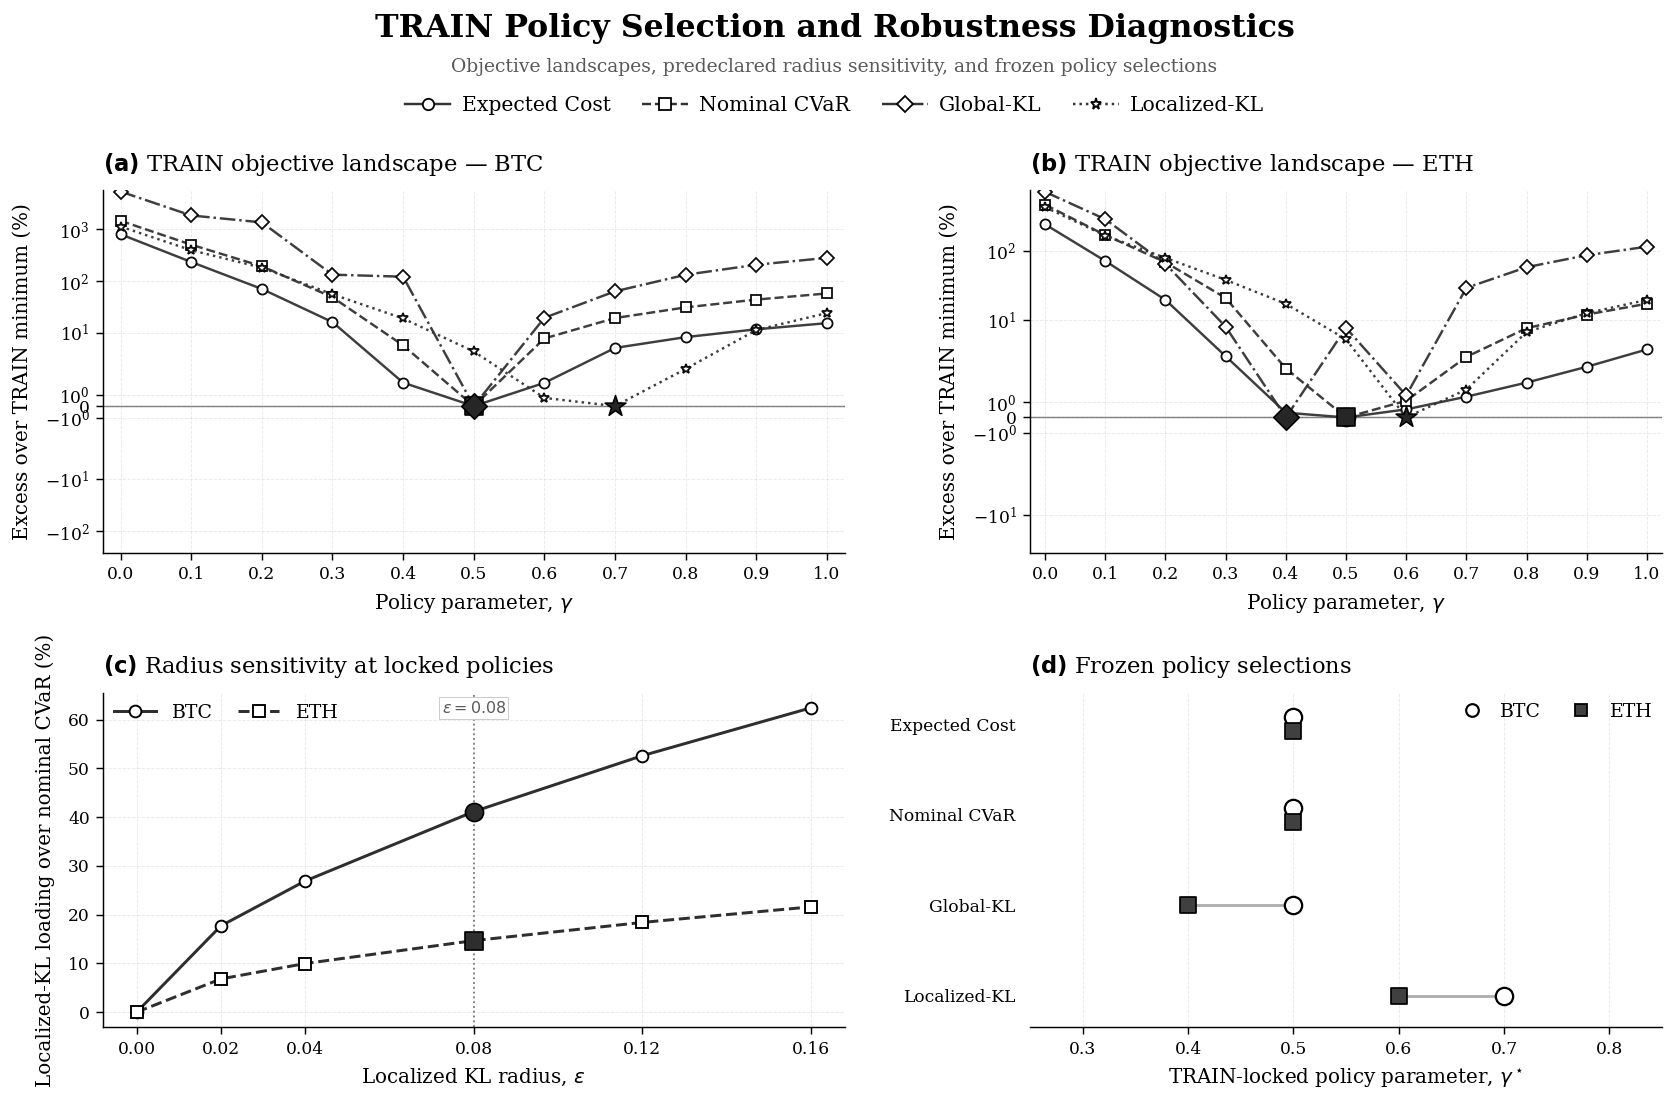

In [6]:
# -------------------------------------------------------------------------
# Figure 5
# -------------------------------------------------------------------------



data_train_obj = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"train_objectives.csv"
)

data_train_raduis = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"TRAIN_RADIUS_SENSITIVITY.csv"
)

data_train_selec = pd.read_csv(
    r"C:/Users/fredy/Downloads/Results_RESS_V1I6_TURBO/"
    r"TRAIN_SELECTION.csv"
)

# Defensive copies
obj = data_train_obj.copy()
rad = data_train_raduis.copy()
sel = data_train_selec.copy()


expected_assets = {"BTCUSDT", "ETHUSDT"}
expected_objectives = {
    "expected_cost",
    "nominal_cvar",
    "global_kl",
    "localized_kl"
}
expected_gamma = np.round(np.arange(0.0, 1.01, 0.1), 1)
expected_eps = np.array([0.00, 0.02, 0.04, 0.08, 0.12, 0.16])


for asset in sorted(expected_assets):
    for objective in sorted(expected_objectives):

        tmp = obj[
            (obj["asset"] == asset) &
            (obj["objective"] == objective)
        ].sort_values("gamma")

        assert len(tmp) == 11
        assert np.allclose(
            tmp["gamma"].to_numpy(),
            expected_gamma,
            atol=1e-12
        )

        selected = sel[
            (sel["asset"] == asset) &
            (sel["objective"] == objective)
        ].iloc[0]

        empirical_argmin = tmp.loc[tmp["value"].idxmin()]

        assert np.isclose(
            selected["gamma"],
            empirical_argmin["gamma"],
            atol=1e-12
        )

        assert np.isclose(
            selected["train_value"],
            empirical_argmin["value"],
            rtol=1e-6,
            atol=1e-10
        )

for asset in sorted(expected_assets):
    for selected_for in sorted(expected_objectives):

        tmp = rad[
            (rad["asset"] == asset) &
            (rad["selected_for"] == selected_for)
        ].sort_values("epsilon")

        assert len(tmp) == 6
        assert np.allclose(
            tmp["epsilon"].to_numpy(),
            expected_eps,
            atol=1e-12
        )

        zero = tmp[np.isclose(tmp["epsilon"], 0.0)].iloc[0]

        assert np.isclose(
            zero["nominal_cvar"],
            zero["localized_kl"],
            rtol=1e-8,
            atol=1e-12
        )

        assert np.isclose(
            zero["nominal_cvar"],
            zero["global_kl"],
            rtol=1e-8,
            atol=1e-12
        )



assets = ["BTCUSDT", "ETHUSDT"]

asset_labels = {
    "BTCUSDT": "BTC",
    "ETHUSDT": "ETH"
}

objectives = ["expected_cost", "nominal_cvar", "global_kl", "localized_kl"]

objective_labels = {
    "expected_cost": "Expected Cost",
    "nominal_cvar": "Nominal CVaR",
    "global_kl": "Global-KL",
    "localized_kl": "Localized-KL"
}

markers = {
    "expected_cost": "o",
    "nominal_cvar": "s",
    "global_kl": "D",
    "localized_kl": "*"
}

linestyles = {
    "expected_cost": "-",
    "nominal_cvar": "--",
    "global_kl": "-.",
    "localized_kl": ":"
}

# =============================================================================
# 3. NORMALIZED TRAIN LANDSCAPES
#
# Relative excess above each objective's own grid minimum:
#
#        100 * [J(gamma) / min_gamma J(gamma) - 1]
#
# This avoids invalid direct scale comparisons across distinct objectives.
# =============================================================================

obj["relative_excess_pct"] = np.nan

for asset in assets:
    for objective in objectives:

        mask = (
            (obj["asset"] == asset) &
            (obj["objective"] == objective)
        )

        jmin = obj.loc[mask, "value"].min()

        obj.loc[mask, "relative_excess_pct"] = (
            100.0 *
            (obj.loc[mask, "value"] / jmin - 1.0)
        )


rad_lkl = rad[rad["selected_for"] == "localized_kl"].copy()


rad_lkl["localized_loading_pct"] = ( 100.0 * (rad_lkl["localized_kl"] / rad_lkl["nominal_cvar"] - 1.0))

rad_lkl["global_loading_pct"] = (100.0 * (rad_lkl["global_kl"] / rad_lkl["nominal_cvar"] - 1.0))


selection_matrix = np.full((len(objectives), len(assets)), np.nan)

for i, objective in enumerate(objectives):
    for j, asset in enumerate(assets):
        selection_matrix[i, j] = sel.loc[(sel["asset"] == asset) & (sel["objective"] == objective), "gamma"].iloc[0]


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10.5,
    "axes.titlesize": 12.5,
    "axes.labelsize": 11.0,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 10.5,
    "axes.linewidth": 0.8,
    "figure.dpi": 130
})

# FIGURE LAYOUT


fig = plt.figure(figsize=(13.4, 8.7))

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[1.04, 0.96],
    width_ratios=[1.08, 0.92],
    hspace=0.40,
    wspace=0.27,
    left=0.080,
    right=0.975,
    bottom=0.095,
    top=0.835
)

ax_a1 = fig.add_subplot(gs[0, 0])
ax_a2 = fig.add_subplot(gs[0, 1])
ax_b  = fig.add_subplot(gs[1, 0])
ax_c  = fig.add_subplot(gs[1, 1])


asset = "BTCUSDT"

for objective in objectives:

    tmp = obj[(obj["asset"] == asset) & (obj["objective"] == objective)].sort_values("gamma")

    ax_a1.plot(
        tmp["gamma"],
        tmp["relative_excess_pct"],
        marker=markers[objective],
        linestyle=linestyles[objective],
        linewidth=1.35,
        markersize=5.6,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        color="0.20",
        alpha=0.95,
        label=objective_labels[objective]
    )

    gstar = sel.loc[(sel["asset"] == asset) & (sel["objective"] == objective), "gamma"].iloc[0]

    ax_a1.scatter(
        [gstar],
        [0.0],
        marker=markers[objective],
        s=100 if objective != "localized_kl" else 145,
        facecolor="0.15",
        edgecolor="black",
        linewidth=0.9,
        zorder=10
    )

ax_a1.axhline(
    0.0,
    color="0.48",
    linewidth=0.8,
    zorder=0
)

ax_a1.set_xlim(-0.025, 1.025)
ax_a1.set_xticks(expected_gamma)

ax_a1.set_yscale(
    "symlog",
    linthresh=5.0,
    linscale=1.0,
    base=10
)

ax_a1.set_xlabel(
    r"Policy parameter, $\gamma$",
    labelpad=5
)

ax_a1.set_ylabel(
    "Excess over TRAIN minimum (%)",
    labelpad=7
)

ax_a1.set_title(
    r"$\bf{(a)}$ TRAIN objective landscape — BTC",
    loc="left",
    pad=11
)

ax_a1.grid(
    axis="both",
    linestyle="--",
    linewidth=0.50,
    alpha=0.27
)

ax_a1.spines["top"].set_visible(False)
ax_a1.spines["right"].set_visible(False)


asset = "ETHUSDT"

for objective in objectives:

    tmp = obj[(obj["asset"] == asset) & (obj["objective"] == objective)].sort_values("gamma")

    ax_a2.plot(
        tmp["gamma"],
        tmp["relative_excess_pct"],
        marker=markers[objective],
        linestyle=linestyles[objective],
        linewidth=1.35,
        markersize=5.6,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        color="0.20",
        alpha=0.95
    )

    gstar = sel.loc[(sel["asset"] == asset) & (sel["objective"] == objective), "gamma"].iloc[0]

    ax_a2.scatter(
        [gstar],
        [0.0],
        marker=markers[objective],
        s=100 if objective != "localized_kl" else 145,
        facecolor="0.15",
        edgecolor="black",
        linewidth=0.9,
        zorder=10
    )

ax_a2.axhline(
    0.0,
    color="0.48",
    linewidth=0.8,
    zorder=0
)

ax_a2.set_xlim(-0.025, 1.025)
ax_a2.set_xticks(expected_gamma)

ax_a2.set_yscale(
    "symlog",
    linthresh=5.0,
    linscale=1.0,
    base=10
)

ax_a2.set_xlabel(r"Policy parameter, $\gamma$", labelpad=5)

ax_a2.set_ylabel(
    "Excess over TRAIN minimum (%)",
    labelpad=7
)

ax_a2.set_title(
    r"$\bf{(b)}$ TRAIN objective landscape — ETH",
    loc="left",
    pad=11
)

ax_a2.grid(
    axis="both",
    linestyle="--",
    linewidth=0.50,
    alpha=0.27
)

ax_a2.spines["top"].set_visible(False)
ax_a2.spines["right"].set_visible(False)


for asset, marker, ls in [("BTCUSDT", "o", "-"), ("ETHUSDT", "s", "--")]:

    tmp = rad_lkl[rad_lkl["asset"] == asset].sort_values("epsilon")

    ax_b.plot(
        tmp["epsilon"],
        tmp["localized_loading_pct"],
        marker=marker,
        linestyle=ls,
        linewidth=1.65,
        markersize=6.5,
        color="0.18",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.05,
        label=asset_labels[asset]
    )

    ref = tmp[np.isclose(tmp["epsilon"], 0.08)].iloc[0]

    ax_b.scatter(
        [ref["epsilon"]],
        [ref["localized_loading_pct"]],
        marker=marker,
        s=100,
        facecolor="0.18",
        edgecolor="black",
        linewidth=0.95,
        zorder=10
    )


# Reference radius
ax_b.axvline(
    0.08,
    color="0.45",
    linewidth=1.0,
    linestyle=":",
    zorder=0
)


ax_b.annotate(
    r"$\varepsilon=0.08$",
    xy=(0.08, 1.0),
    xycoords=("data", "axes fraction"),
    xytext=(0, -4),
    textcoords="offset points",
    ha="center",
    va="top",
    fontsize=8.8,
    color="0.35",
    bbox=dict(
        boxstyle="square,pad=0.16",
        facecolor="white",
        edgecolor="0.80",
        linewidth=0.55
    )
)

ax_b.set_xticks(expected_eps)

ax_b.set_xlabel(
    r"Localized KL radius, $\varepsilon$",
    labelpad=5
)

ax_b.set_ylabel(
    "Localized-KL loading over nominal CVaR (%)",
    labelpad=7
)

ax_b.set_title(
    r"$\bf{(c)}$ Radius sensitivity at locked policies",
    loc="left",
    pad=11
)

ax_b.grid(
    axis="both",
    linestyle="--",
    linewidth=0.50,
    alpha=0.27
)

ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)

ax_b.legend(
    frameon=False,
    loc="upper left",
    ncol=2,
    handlelength=2.2,
    columnspacing=1.35,
    borderaxespad=0.2
)

ypos = np.arange(len(objectives))[::-1]

offset = 0.075

for i, objective in enumerate(objectives):

    y = ypos[i]

    btc_gamma = float(selection_matrix[i, 0])
    eth_gamma = float(selection_matrix[i, 1])

    if not np.isclose(btc_gamma, eth_gamma):

        ax_c.plot(
            [btc_gamma, eth_gamma],
            [y, y],
            color="0.68",
            linewidth=1.55,
            solid_capstyle="round",
            zorder=1
        )

        ax_c.scatter(
            btc_gamma,
            y,
            marker="o",
            s=92,
            facecolor="white",
            edgecolor="black",
            linewidth=1.25,
            zorder=4
        )

        ax_c.scatter(
            eth_gamma,
            y,
            marker="s",
            s=82,
            facecolor="0.25",
            edgecolor="black",
            linewidth=0.95,
            zorder=5
        )

    else:

        ax_c.plot(
            [btc_gamma, eth_gamma],
            [y + offset, y - offset],
            color="0.72",
            linewidth=1.1,
            zorder=1
        )

        ax_c.scatter(
            btc_gamma,
            y + offset,
            marker="o",
            s=92,
            facecolor="white",
            edgecolor="black",
            linewidth=1.25,
            zorder=4
        )

        ax_c.scatter(
            eth_gamma,
            y - offset,
            marker="s",
            s=82,
            facecolor="0.25",
            edgecolor="black",
            linewidth=0.95,
            zorder=5
        )


ax_c.set_xlim(0.25, 0.85)
ax_c.set_xticks(np.arange(0.3, 0.81, 0.1))

ax_c.set_ylim(-0.35, len(objectives) - 0.65)

ax_c.set_yticks(ypos)
ax_c.set_yticklabels(["Expected Cost", "Nominal CVaR", "Global-KL", "Localized-KL"])

ax_c.set_xlabel(r"TRAIN-locked policy parameter, $\gamma^\star$", labelpad=5)

ax_c.set_title(
    r"$\bf{(d)}$ Frozen policy selections",
    loc="left",
    pad=11
)

ax_c.grid(
    axis="x",
    linestyle="--",
    linewidth=0.50,
    alpha=0.27
)

ax_c.spines["top"].set_visible(False)
ax_c.spines["right"].set_visible(False)
ax_c.spines["left"].set_visible(False)

ax_c.tick_params(
    axis="y",
    length=0,
    pad=8
)

# Dedicated asset legend for panel (d)
selection_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=7.0,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.2,
        label="BTC"
    ),
    Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        markersize=6.8,
        markerfacecolor="0.25",
        markeredgecolor="black",
        label="ETH"
    )
]

ax_c.legend(
    handles=selection_handles,
    frameon=False,
    loc="upper right",
    ncol=2,
    handletextpad=0.45,
    columnspacing=1.15,
    borderaxespad=0.15
)

objective_handles = [
    Line2D(
        [0], [0],
        marker=markers[o],
        linestyle=linestyles[o],
        linewidth=1.35,
        markersize=6.3,
        markerfacecolor="white",
        markeredgecolor="black",
        color="0.20",
        label=objective_labels[o]
    )
    for o in objectives
]

fig.legend(
    handles=objective_handles,
    loc="upper center",
    bbox_to_anchor=(0.50, 0.935),
    ncol=4,
    fontsize=11.3,
    frameon=False,
    columnspacing=1.55,
    handlelength=2.25,
    handletextpad=0.55
)


fig.suptitle(
    "TRAIN Policy Selection and Robustness Diagnostics",
    fontsize=17.5,
    fontweight="bold",
    y=0.992
)

fig.text(
    0.50,
    0.944,
    "Objective landscapes, predeclared radius sensitivity, "
    "and frozen policy selections",
    ha="center",
    va="center",
    fontsize=10.4,
    color="0.35"
)

plt.show()